<a href="https://colab.research.google.com/github/SandhuruT/Data_Science_01/blob/main/Data_Science_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test)

df_hr = pd.read_csv('/content/hr_attrition.csv')
df_hr.head()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- job_satisfaction
- num_companies_worked
- overtime
- percent_salary_hike
Feature names seen at fit time, yet now missing:
- years_in_role


In [83]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   employee_id               200 non-null    object
 1   age                       200 non-null    int64 
 2   gender                    200 non-null    object
 3   department                200 non-null    object
 4   job_role                  200 non-null    object
 5   education                 200 non-null    object
 6   years_at_company          200 non-null    int64 
 7   years_in_role             200 non-null    int64 
 8   monthly_income            200 non-null    object
 9   percent_salary_hike       200 non-null    int64 
 10  job_satisfaction          200 non-null    int64 
 11  work_life_balance         200 non-null    int64 
 12  overtime                  200 non-null    object
 13  distance_from_home        200 non-null    int64 
 14  num_companies_worked      

In [84]:
df_hr.describe()

,age,years_at_company,years_in_role,percent_salary_hike,job_satisfaction,work_life_balance,distance_from_home,num_companies_worked,training_times_last_year
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,38.405000,9.330000,8.520000,13.56500,2.835000,2.540000,10.320000,3.065000,2.290000
std,8.377463,6.065066,5.892641,3.55089,0.837425,0.663779,8.255201,2.575645,1.005462
min,18.000000,0.000000,0.000000,11.00000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,32.000000,5.000000,4.000000,11.00000,2.000000,2.000000,3.000000,1.000000,2.000000
50%,38.000000,9.000000,8.000000,13.00000,3.000000,3.000000,9.000000,3.000000,2.000000
75%,44.000000,14.000000,13.000000,14.00000,3.000000,3.000000,16.250000,4.000000,3.000000
max,59.000000,25.000000,24.000000,30.00000,4.000000,3.000000,29.000000,15.000000,5.000000


In [85]:
df_is_null = df_hr.isnull().sum()
df_is_null

,0
employee_id,0
age,0
gender,0
department,0
job_role,0
education,0
years_at_company,0
years_in_role,0
monthly_income,0
percent_salary_hike,0


In [86]:
df_hr.duplicated().sum()

np.int64(0)

In [87]:
df_hr.dtypes

,0
employee_id,object
age,int64
gender,object
department,object
job_role,object
education,object
years_at_company,int64
years_in_role,int64
monthly_income,object
percent_salary_hike,int64


In [88]:
# changeing mothly income object dtype to int
df_hr['monthly_income'] = pd.to_numeric(df_hr['monthly_income'], errors='coerce')
df_hr['monthly_income'] = df_hr['monthly_income'].fillna(df_hr['monthly_income'].median())
df_hr['monthly_income'] = df_hr['monthly_income'].astype(int)
df_hr.dtypes

,0
employee_id,object
age,int64
gender,object
department,object
job_role,object
education,object
years_at_company,int64
years_in_role,int64
monthly_income,int64
percent_salary_hike,int64


The code snippet you provided performs a type conversion on the 'monthly_income' column of your DataFrame `df_hr`.

Here's a breakdown of each line:

1.  `df_hr['monthly_income'] = pd.to_numeric(df_hr['monthly_income'], errors='coerce')`
    *   `pd.to_numeric()`: This pandas function is used to convert an argument to a numeric type.
    *   `errors='coerce'`: This is a very important argument here. If pandas encounters any value in the 'monthly_income' column that cannot be converted to a number (e.g., text like '2deferrals'), it will replace that value with `NaN` (Not a Number) instead of raising an error. This prevents the `ValueError` you encountered earlier.

2.  `df_hr['monthly_income'] = df_hr['monthly_income'].fillna(0).astype('int64')`
    *   `.fillna(0)`: After the previous step, any non-numeric values were converted to `NaN`. This method fills all `NaN` values in the 'monthly_income' column with `0`.
    *   `.astype('int64')`: Finally, this converts the entire 'monthly_income' column to a 64-bit integer type. This ensures that all monthly income values are stored as whole numbers.

3.  `df_hr.dtypes`
    *   This line simply displays the data types of all columns in the `df_hr` DataFrame. This is used to verify that the 'monthly_income' column has indeed been successfully converted to `int64`.

In [89]:
df_hr['attrition'] = (df_hr['attrition'] == 'Yes').astype(int)

In [90]:
df_hr.dtypes

,0
employee_id,object
age,int64
gender,object
department,object
job_role,object
education,object
years_at_company,int64
years_in_role,int64
monthly_income,int64
percent_salary_hike,int64


In [91]:
df_hr.head()

,employee_id,age,gender,department,job_role,education,years_at_company,years_in_role,monthly_income,percent_salary_hike,job_satisfaction,work_life_balance,overtime,distance_from_home,num_companies_worked,training_times_last_year,attrition
0,E001,41,Male,Sales,Sales Executive,Bachelor,6,4,5993,11,3,1,Yes,1,8,0,1
1,E002,49,Female,Research,Research Scientist,Master,10,7,5130,23,2,3,No,8,1,3,0
2,E003,37,Male,Research,Lab Technician,Bachelor,0,0,2090,15,3,3,Yes,2,6,3,1
3,E004,33,Female,Research,Research Scientist,Master,8,7,2909,11,3,3,Yes,3,1,2,0
4,E005,27,Male,Research,Lab Technician,Bachelor,2,2,3468,12,2,3,No,2,9,2,0


In [92]:
# what is over all attrition rate?
attrition_rate = df_hr['attrition'].mean() * 100
print(f"Overall attrition rate: {attrition_rate:.2f}%")


Overall attrition rate: 39.00%


In [93]:
df_hr['attrition'].value_counts()

,count
attrition,
0,122
1,78


In [94]:
# Which department has the highest attrition?
department_attrition = df_hr.groupby('department')['attrition'].mean().mul(100).round(2)
department_attrition

,attrition
department,
HR,0.00
Research,27.46
Sales,100.00


In [95]:
df_hr.dtypes

,0
employee_id,object
age,int64
gender,object
department,object
job_role,object
education,object
years_at_company,int64
years_in_role,int64
monthly_income,int64
percent_salary_hike,int64


In [96]:
#Do employees who work overtime leave more?
print(df_hr['overtime'].value_counts())

overtime
No     121
Yes     79
Name: count, dtype: int64


In [97]:
df_hr.head()

,employee_id,age,gender,department,job_role,education,years_at_company,years_in_role,monthly_income,percent_salary_hike,job_satisfaction,work_life_balance,overtime,distance_from_home,num_companies_worked,training_times_last_year,attrition
0,E001,41,Male,Sales,Sales Executive,Bachelor,6,4,5993,11,3,1,Yes,1,8,0,1
1,E002,49,Female,Research,Research Scientist,Master,10,7,5130,23,2,3,No,8,1,3,0
2,E003,37,Male,Research,Lab Technician,Bachelor,0,0,2090,15,3,3,Yes,2,6,3,1
3,E004,33,Female,Research,Research Scientist,Master,8,7,2909,11,3,3,Yes,3,1,2,0
4,E005,27,Male,Research,Lab Technician,Bachelor,2,2,3468,12,2,3,No,2,9,2,0


Text(0.5, 1.0, 'Average Monthly Income by Department')

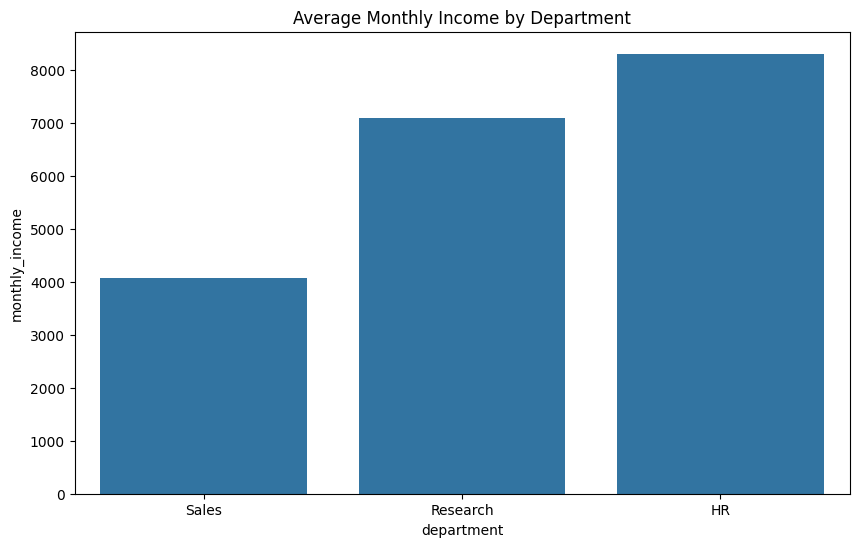

In [98]:
#  Plot average monthly income by department.
plt.figure(figsize=(10, 6))
sns.barplot(x='department', y='monthly_income', data=df_hr,errorbar=None)
plt.title('Average Monthly Income by Department')


In [99]:
# Find top 3 factors that differ most between employees who left vs stayed
df_hr.groupby('attrition').mean(numeric_only=True).T

attrition,0,1
age,41.606557,33.397436
years_at_company,11.450820,6.012821
years_in_role,10.467213,5.474359
monthly_income,8703.352459,3357.115385
percent_salary_hike,14.614754,11.923077
job_satisfaction,3.147541,2.346154
work_life_balance,2.991803,1.833333
distance_from_home,8.106557,13.782051
num_companies_worked,2.180328,4.448718
training_times_last_year,2.852459,1.410256


In [100]:
# Machine Learning (Feature Engineering)
Feature = ['age','years_at_company','years_in_role','monthly_income','work_life_balance','distance_from_home']

In [101]:
X = df_hr[Feature].copy()
Y = df_hr['attrition']

In [102]:
# Trsin / Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [103]:
print(f"training rowes : {len(X_train)}")
print(f"testing rowes : {len(X_test)}")

training rowes : 160
testing rowes : 40


In [104]:
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train,Y_train)

print("Model trained succssfully")
print(f"Number of leaves: {model.get_n_leaves()}")  # number of path through the trees
print(f"Tree depth: {model.get_depth()}")   # number of question asked

Model trained succssfully
Number of leaves: 7
Tree depth: 4


In [105]:
print(f"Accuracy: {accuracy_score(Y_test,y_pred) *100:2f}%")
print("Classification Report:")
print(classification_report(Y_test,y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test,y_pred))

Accuracy: 97.500000%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.97        19

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

Confusion Matrix:
[[20  1]
 [ 0 19]]


In [106]:
# Hyperparameter Tuning
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# Load and prepare
df_hr['attrition'] = (df_hr['attrition'] == 'Yes').astype(int)
df_hr['overtime'] = (df_hr['overtime'] == 'Yes').astype(int)

# Fix dirty value
df_hr['monthly_income'] = pd.to_numeric(df_hr['monthly_income'], errors='coerce')
df_hr['monthly_income'].fillna(df_hr['monthly_income'].median(), inplace=True)

# Features
features = ['age', 'monthly_income', 'years_at_company', 'overtime',
            'job_satisfaction', 'work_life_balance', 'distance_from_home',
            'num_companies_worked', 'percent_salary_hike']

X = df_hr[features]
y = df_hr['attrition']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Data ready: {X_resampled.shape}")

/tmp/ipykernel_714/2171037517.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hr['monthly_income'].fillna(df_hr['monthly_income'].median(), inplace=True)


ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

# Fit on resampled data
grid_search.fit(X_resampled, y_resampled)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best recall score: {grid_search.best_score_:.2f}")